# PROJECT CARD

**The paper:** Ke, Ong, Shih, Yin (2012). Three-Dimensional Structures Self-Assembled from DNA Bricks

**The data object:** 6H x 10H x 128B cuboid structure assembly yields at eight different $MgCl_2$ concentrations

**The random variable chosen:** assembly yield (%) as a function of the $MgCl_2$ concentration (mM) -> Y | [$MgCL_2$]

**What the paper does:** The paper demonstrates a self-assembly of DNA bricks which represent 3D DNA nanostructures. One part of the study shows that assembly yields depend on the annealing conditions with and optimal yield at 40 mM $MgCl_2$. Higher and lower concentrations reduce yield. 

**The generative model proposed:** Gaussian Model
$$\mu_y(x)=A\exp[-\frac{(x-\mu)^2}{2\omega^2}]$$

**Parameters and assumptions:**
1. The model assumption is a Gaussian model with noramally distributed errors. 
2. [$MgCl_2$] is expected to influence yield
3. There is an optimal concentration where yield is highest. 
4. The measurement errors are independent of one another.

$A$: max. yield

$\mu$: optimal $MgCl_2$ concentration

$\omega$: width oft optimal

$\sigma$: standard deviation of the experimental error

**The forward simulation:**
Testing the model based on chosen parameters to see what results we get. Theta are chosen and we get a simulated yield. 

**The parameterization/fitting:**
The experimental data are now given and the model parameters will be adjusted to the observed data. Therefore, we used a negative log-likelihood approach to identify the optimal parameter combination. 

**What/if the model adds to the paper:**
It provides a simplified mathematical description of the relationship between $MgCl_2$ concentration and assembly yield (obeying the model limitations written below). Therefore, it allows estimation of optimal $MgCl_2$ concentration and prediction of expected yield at $MgCl_2§ concentrations that were not directly measured. 

**Model limitiations/how ot breaks:**
1. The general DNA assembly is depending on more factors than just the $MgCl_2$ concentration (e.g. temperature, stochiometry, annealing protocol), resulting in the model not being able to predict actual yield under arbitrary experimental conditions. 
2. Model is simplified. The Gaussian curve is symmetric which might not reflect the actual biological relationship of self-assembly and $MgCl_2$ concentration. 
3. The model assumes approximately constant and normally distributed errors not taking into account changing measurement variability with $MgCl_2$ concentration. 
4. The model only describes an empirical relationship rather than the molecular mechanism of DNA Brick self-assembly. 

### Modules/Libraries necessary

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import sys

### Data the paper presents

Experimental Data from Fig. S15:.
   mgcl2_mM  yield_mass_ng  yield_percent
0        20            250            2.5
1        30            370            3.7
2        40            370            3.7
3        50            360            3.6
4        60            300            3.0
5        70            260            2.6
6        80            170            1.7

Optimal [MgCl₂]: 40 mM
Maximum yield: 3.7%


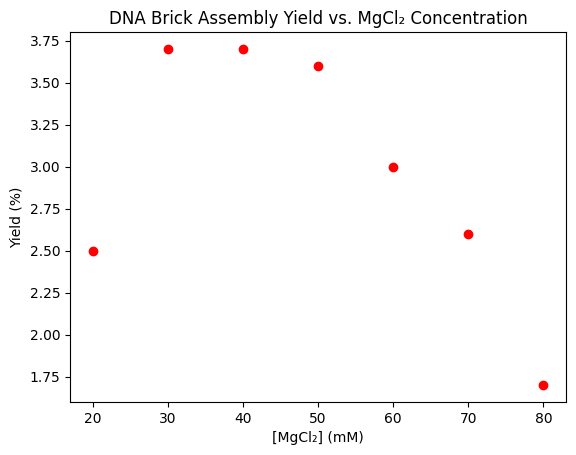

In [4]:
sys.path.append('data')
from data import conc, yield_mass, yield_perc
df_data = pd.DataFrame({'mgcl2_mM': conc,'yield_mass_ng': yield_mass, 'yield_percent': yield_perc})

print("Experimental Data from Fig. S15:.")
print(df_data)
print(f"\nOptimal [MgCl₂]: 40 mM")
print(f"Maximum yield: {df_data['yield_percent'].max():.1f}%")

plt.figure()
plt.scatter(df_data['mgcl2_mM'], df_data['yield_percent'], color='red', label='Measured yields')
plt.xlabel('[MgCl₂] (mM)')
plt.ylabel('Yield (%)')
plt.title('DNA Brick Assembly Yield vs. MgCl₂ Concentration')
plt.show()

### Simulation

In [5]:
A = 1664525
C = 1013904223
M = 2 ** 32


def lcg(state, a, c, m):
    state = (a * state + c) % m
    return state


def uniforms_from_lcg(k, seed):
    out = [0.] * k
    state = seed
    for i in range(k):
        state = lcg(state, A, C, M)
        out[i] = state / M
    return out


def binomial_sample_from_lcg(n, p, size=1000, seed=12345):
    samples = []
    state = seed
    for sample_idx in range(size):
        successes = 0
        for trial in range(n):
            state = lcg(state, A, C, M)
            r = state / M
            if r < p:
                successes += 1
        samples.append(successes)
    return np.array(samples)

def normal(x, mu, sigma):
    return 1 / (sigma * (2 * math.pi) ** 0.5) * math.exp(-((x-mu) ** 2) / (2 * sigma ** 2))


def gaussian(x, A, mu, width):
    return A * math.exp(-((x - mu) ** 2) / (2 * width ** 2))

#### Testing Simulation

[2.244163440936744, 3.2652385395630033, 3.7, 3.2652385395630033, 2.244163440936744, 1.201214129225894, 0.5007405479754671]


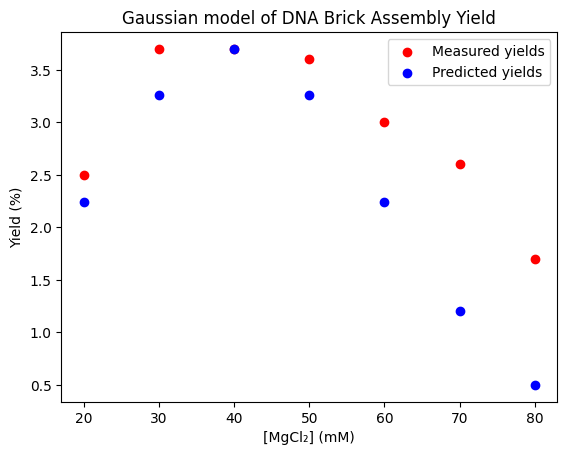

In [6]:
A = 3.7 
mu = 40
width = 20

predicted_yields = [0.0] * len(df_data)

for i in range(len(df_data)):
    x = df_data['mgcl2_mM'][i]
    predicted_yields[i] = gaussian(x, A, mu, width)

print(predicted_yields)

plt.figure()
plt.scatter(df_data['mgcl2_mM'], df_data['yield_percent'], color='red', label='Measured yields')

plt.scatter(df_data['mgcl2_mM'], predicted_yields, color='blue', label='Predicted yields')
plt.xlabel('[MgCl₂] (mM)')
plt.ylabel('Yield (%)')
plt.title('Gaussian model of DNA Brick Assembly Yield')
plt.legend()
plt.show()

Gaussian Distribution fits the data rather well. Now the optimal parameters need to be discovered.

#### Parameter Estimation


Best-fit parameters:
Maximum yield (A): 3.7
Optimal MgCl2 concentration (mu): 43 mM
Gaussian width: 30
Best NLL: -2.210243810596133


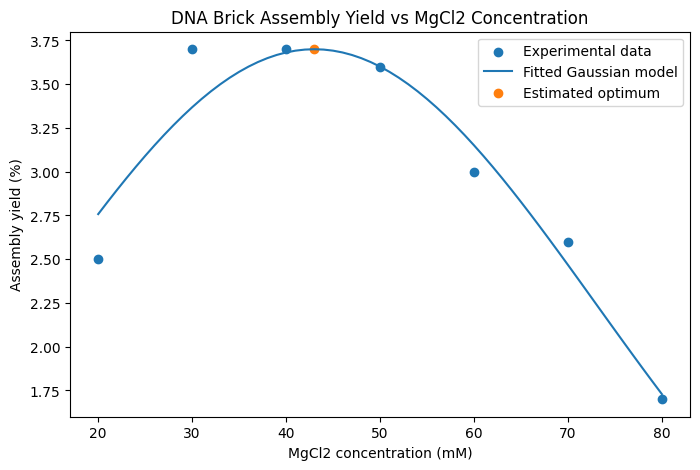

In [19]:
def nll(A, mu, width):
    nll = 0.0
    residuals = []
    for i in range(len(df_data)):
        x = df_data['mgcl2_mM'][i]
        observed = df_data['yield_percent'][i]
        predicted = gaussian(x, A, mu, width)
        residuals.append(observed - predicted)
    sigma = np.sqrt(np.mean(np.array(residuals) ** 2))

    for i in range(len(df_data)):
        x = df_data['mgcl2_mM'][i]
        observed = df_data['yield_percent'][i]
        predicted = gaussian(x, A, mu, width)
        probability = normal(observed, predicted, sigma)
        nll -= math.log(probability)
    return nll, sigma


A_values = [2.5 + 0.1 * i for i in range(21)]
mu_values = [20 + 1 * i for i in range(41)]
width_values = [5 + 1 * i for i in range(31)]

best_A = A_values[0]
best_mu = mu_values[0]
best_width = width_values[0]

best_nll, best_sigma = nll(best_A, best_mu, best_width,)

for A in A_values:
    for mu in mu_values:
        for width in width_values:

            current_nll, current_sigma = nll(A, mu, width,)

            if current_nll < best_nll:
                best_nll = current_nll
                best_A = A
                best_mu = mu
                best_width = width
                best_sigma = current_sigma

print("Best-fit parameters:")
print("Maximum yield (A):", best_A)
print("Optimal MgCl2 concentration (mu):", best_mu, "mM")
print("Gaussian width:", best_width)
print("Best NLL:", best_nll)


model_x = [20 + i for i in range(61)]
model_y = [0.0] * len(model_x)

for i in range(len(model_x)):
    model_y[i] = gaussian(model_x[i], best_A, best_mu, best_width)


plt.figure(figsize=(8, 5))

plt.scatter(df_data['mgcl2_mM'], df_data['yield_percent'], label='Experimental data')

plt.plot(model_x, model_y, label='Fitted Gaussian model')

plt.scatter([best_mu], [best_A], label='Estimated optimum')

plt.xlabel('MgCl2 concentration (mM)')
plt.ylabel('Assembly yield (%)')
plt.title('DNA Brick Assembly Yield vs MgCl2 Concentration')

plt.legend()
plt.show()

### Validation

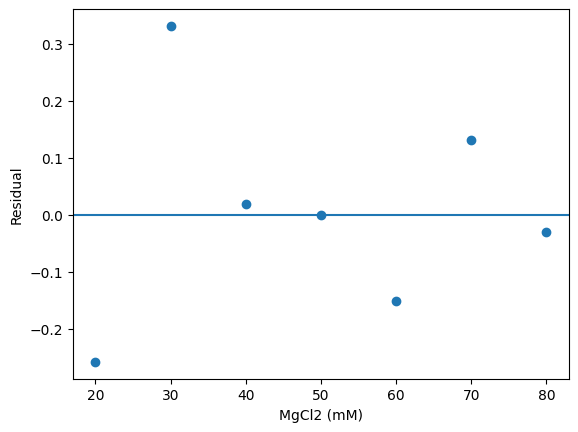

In [17]:
residuals = []

for i in range(len(df_data)):
    x = df_data['mgcl2_mM'][i]
    observed = df_data['yield_percent'][i]

    predicted = gaussian(
        x,
        best_A,
        best_mu,
        best_width
    )

    residuals.append(observed - predicted)

plt.scatter(df_data["mgcl2_mM"], residuals)
plt.axhline(0)
plt.xlabel("MgCl2 (mM)")
plt.ylabel("Residual")
plt.show()